# **Project 4 — Data Visualization**

## **Step 0 — Import Libraries & Global Style Settings**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Global clean style — applied to ALL charts automatically ──
plt.rcParams.update({
    'font.family'        : 'DejaVu Sans',
    'axes.spines.top'    : False,   # remove top border
    'axes.spines.right'  : False,   # remove right border
    'axes.spines.left'   : False,   # remove left border
    'axes.grid'          : True,
    'grid.color'         : '#f0f0f0',  # very light grid
    'grid.linewidth'     : 0.7,
    'axes.axisbelow'     : True,    # grid behind bars
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'xtick.bottom'       : False,   # remove tick marks
    'ytick.left'         : False,
})

# ── Color palette ──
GREY  = '#CCCCCC'   # all non-spotlight bars
BLUE  = '#1A6FBF'   # ONE accent color for key insight
RED   = '#C0392B'   # only for urgent warnings
DARK  = '#333333'   # text color

print("Libraries imported and style set!")

Libraries imported and style set!


## **Step 1 — Load Dataset**

In [3]:
df = pd.read_excel('Dataset for Data Analytics.xlsx')

# Apply Project 1 cleaning
df['CouponCode'] = df['CouponCode'].fillna('NO_COUPON')
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

print("Dataset loaded!")
print("Shape:", df.shape)
df.head()

Dataset loaded!
Shape: (1200, 15)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023-01
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024-08
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024-02
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023-10
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025-05


##  **Chart 1 — Revenue by Product (Horizontal Bar)**

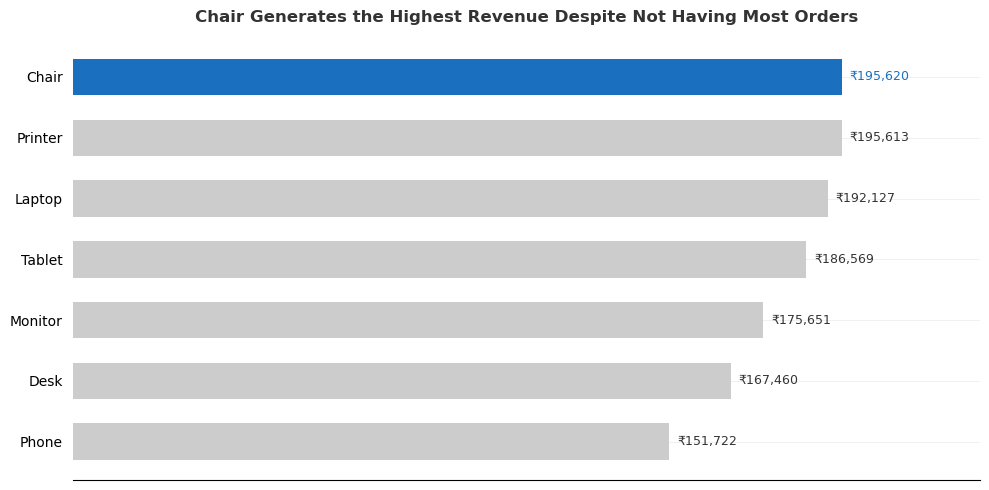

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

# Group and sort data
prod_rev = df.groupby('Product')['TotalPrice'].sum().sort_values()

# Spotlight — Blue only on Chair, Grey for everything else
colors = [BLUE if p == 'Chair' else GREY for p in prod_rev.index]

# Draw bars
bars = ax.barh(prod_rev.index, prod_rev.values, color=colors, height=0.6)

# Direct labels on each bar
for bar, val in zip(bars, prod_rev.values):
    ax.text(val + 2000,
            bar.get_y() + bar.get_height()/2,
            f'₹{val:,.0f}',
            va='center', ha='left', fontsize=9,
            color=BLUE if val == prod_rev.max() else DARK)

# Action title — states the conclusion
ax.set_title('Chair Generates the Highest Revenue Despite Not Having Most Orders',
             fontsize=12, fontweight='bold', color=DARK, pad=12)

ax.get_xaxis().set_visible(False)   # hide x axis — labels do the job
ax.set_xlim(0, prod_rev.max() * 1.18)

plt.tight_layout()
plt.savefig('chart1_revenue_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

## **Chart 2 — Monthly Revenue Trend (Line Chart)**

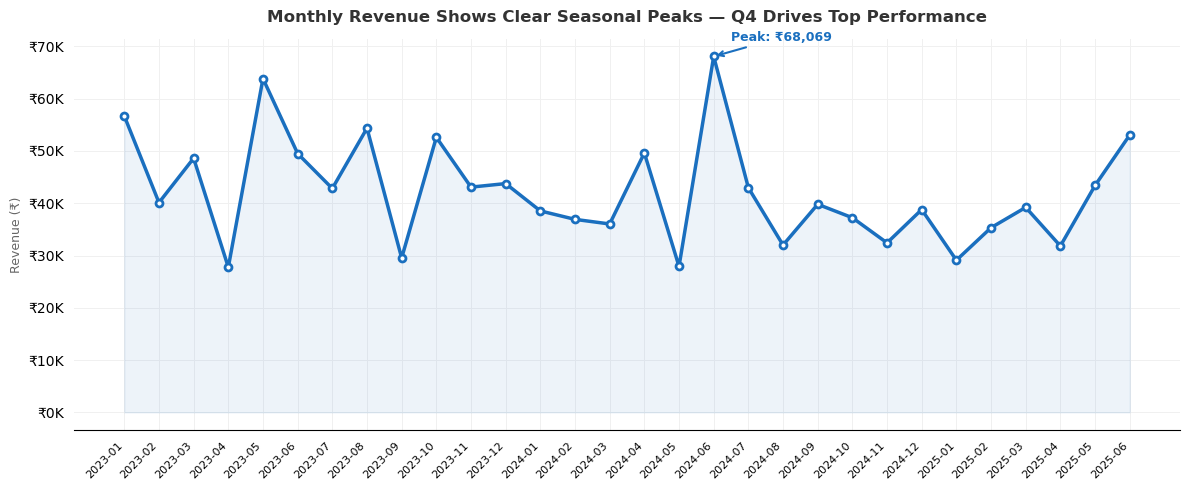

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

monthly = df.groupby('Month')['TotalPrice'].sum()
months_str = [str(m) for m in monthly.index]

# Line chart — best for trends over time
ax.plot(months_str, monthly.values,
        color=BLUE, linewidth=2.5,
        marker='o', markersize=5,
        markerfacecolor='white', markeredgecolor=BLUE, markeredgewidth=2)

# Light fill under the line
ax.fill_between(months_str, monthly.values, alpha=0.08, color=BLUE)

# Annotate the peak month
peak_idx = monthly.values.argmax()
ax.annotate(f'Peak: ₹{monthly.values[peak_idx]:,.0f}',
            xy=(months_str[peak_idx], monthly.values[peak_idx]),
            xytext=(peak_idx + 0.5, monthly.values[peak_idx] + 3000),
            fontsize=9, color=BLUE, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.5))

ax.set_title('Monthly Revenue Shows Clear Seasonal Peaks — Q4 Drives Top Performance',
             fontsize=12, fontweight='bold', color=DARK, pad=12)
ax.set_ylabel('Revenue (₹)', fontsize=9, color='#666')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
plt.xticks(rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('chart2_monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## **Chart 3 — Order Status (Horizontal Bar)**

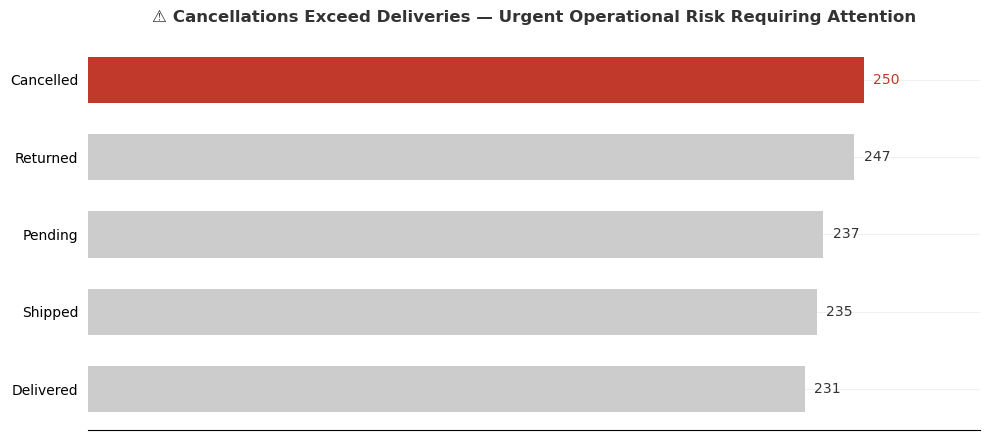

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))

status_counts = df['OrderStatus'].value_counts().sort_values()

# Red spotlight on Cancelled — urgent warning
colors = [RED if s == 'Cancelled' else GREY for s in status_counts.index]

bars = ax.barh(status_counts.index, status_counts.values, color=colors, height=0.6)

for bar, val in zip(bars, status_counts.values):
    ax.text(val + 3,
            bar.get_y() + bar.get_height()/2,
            str(val),
            va='center', ha='left', fontsize=10,
            color=RED if val == status_counts.max() else DARK)

ax.set_title('⚠ Cancellations Exceed Deliveries — Urgent Operational Risk Requiring Attention',
             fontsize=12, fontweight='bold', color=DARK, pad=12)
ax.get_xaxis().set_visible(False)
ax.set_xlim(0, status_counts.max() * 1.15)

plt.tight_layout()
plt.savefig('chart3_order_status.png', dpi=150, bbox_inches='tight')
plt.show()

## **Chart 4 — Revenue by Referral Source (Column Bar)**

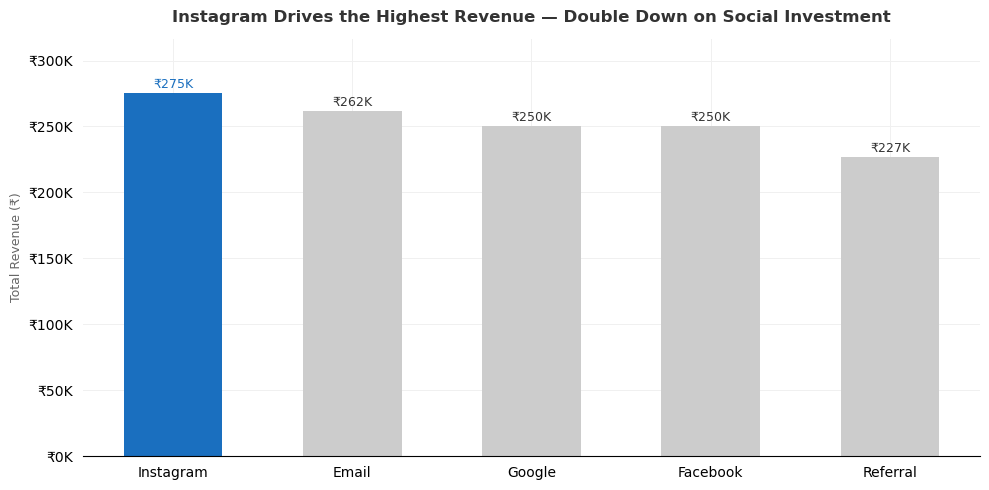

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ref_rev = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)

# Blue spotlight on Instagram
colors = [BLUE if r == 'Instagram' else GREY for r in ref_rev.index]

bars = ax.bar(ref_rev.index, ref_rev.values, color=colors, width=0.55)

for bar, val in zip(bars, ref_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1500,
            f'₹{val/1000:.0f}K',
            ha='center', va='bottom', fontsize=9,
            color=BLUE if val == ref_rev.max() else DARK)

ax.set_title('Instagram Drives the Highest Revenue — Double Down on Social Investment',
             fontsize=12, fontweight='bold', color=DARK, pad=12)
ax.set_ylabel('Total Revenue (₹)', fontsize=9, color='#666')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
ax.set_ylim(0, ref_rev.max() * 1.15)

plt.tight_layout()
plt.savefig('chart4_referral_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## **Chart 5 — Avg Order Value by Payment Method (Column Bar)**

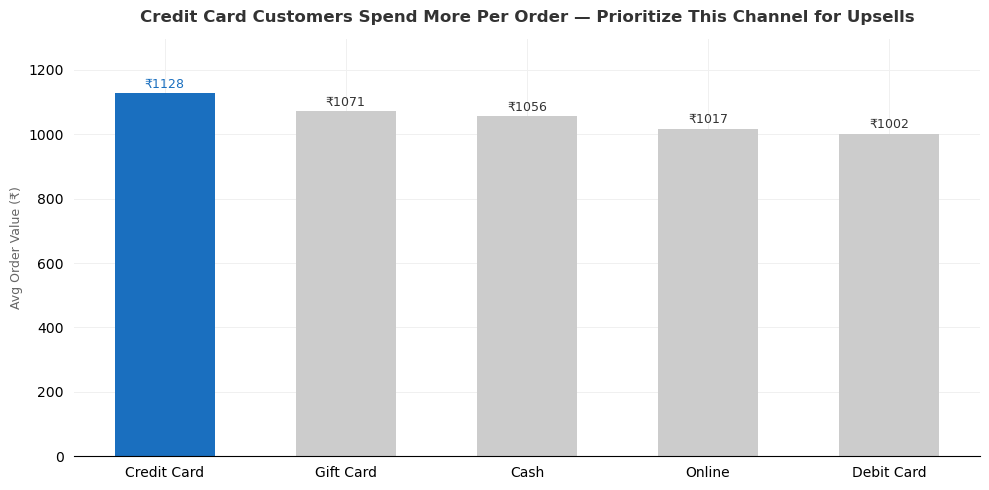

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

pay_avg = df.groupby('PaymentMethod')['TotalPrice'].mean().sort_values(ascending=False)
max_pay = pay_avg.idxmax()

# Blue spotlight on highest avg payment method
colors = [BLUE if p == max_pay else GREY for p in pay_avg.index]

bars = ax.bar(pay_avg.index, pay_avg.values, color=colors, width=0.55)

for bar, val in zip(bars, pay_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 8,
            f'₹{val:.0f}',
            ha='center', va='bottom', fontsize=9,
            color=BLUE if val == pay_avg.max() else DARK)

ax.set_title(f'{max_pay} Customers Spend More Per Order — Prioritize This Channel for Upsells',
             fontsize=12, fontweight='bold', color=DARK, pad=12)
ax.set_ylabel('Avg Order Value (₹)', fontsize=9, color='#666')
ax.set_ylim(0, pay_avg.max() * 1.15)

plt.tight_layout()
plt.savefig('chart5_payment_avg_order.png', dpi=150, bbox_inches='tight')
plt.show()

## **Chart 6 — UnitPrice vs TotalPrice Correlation (Scatter Plot)**

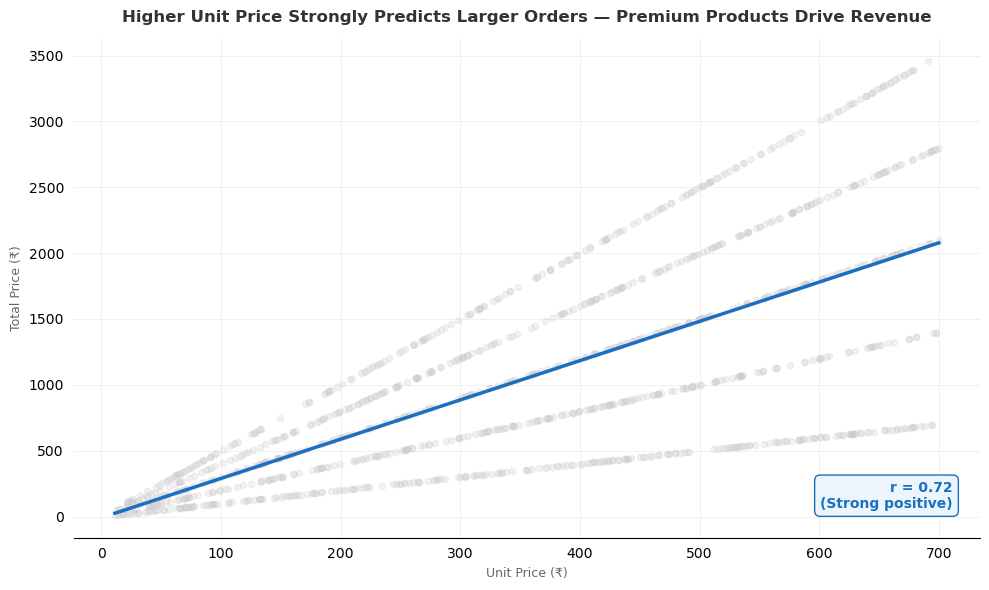

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

# All dots in grey — don't distract from the trend line
ax.scatter(df['UnitPrice'], df['TotalPrice'], alpha=0.25, color=GREY, s=20)

# Regression line in blue — this is the insight
m, b = np.polyfit(df['UnitPrice'], df['TotalPrice'], 1)
x_line = np.linspace(df['UnitPrice'].min(), df['UnitPrice'].max(), 100)
ax.plot(x_line, m * x_line + b, color=BLUE, linewidth=2.5)

# Annotation box showing r value
ax.text(0.97, 0.06, 'r = 0.72\n(Strong positive)',
        transform=ax.transAxes,
        ha='right', fontsize=10, color=BLUE, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#EBF5FB', edgecolor=BLUE))

ax.set_title('Higher Unit Price Strongly Predicts Larger Orders — Premium Products Drive Revenue',
             fontsize=12, fontweight='bold', color=DARK, pad=12)
ax.set_xlabel('Unit Price (₹)', fontsize=9, color='#666')
ax.set_ylabel('Total Price (₹)', fontsize=9, color='#666')

plt.tight_layout()
plt.savefig('chart6_unitprice_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## **Chart 7 — TotalPrice Distribution (Histogram)**

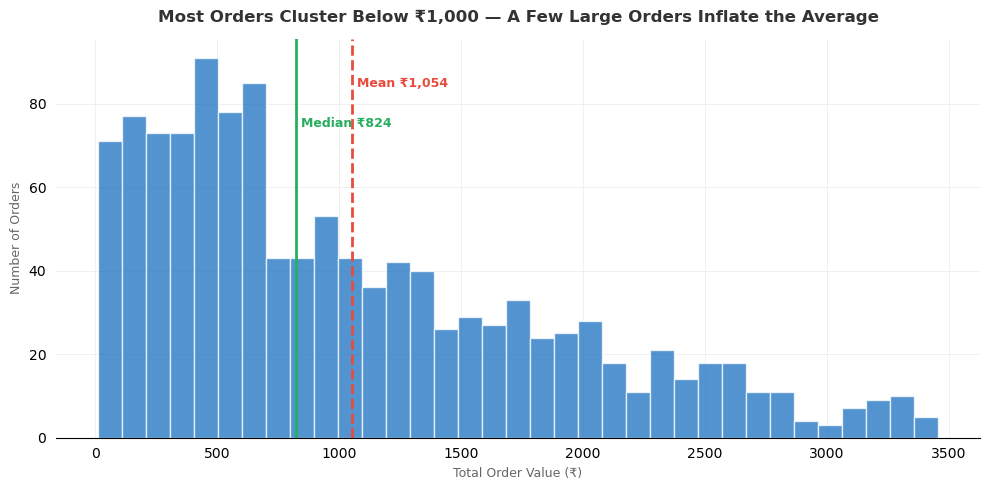

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['TotalPrice'], bins=35, color=BLUE, alpha=0.75, edgecolor='white')

mean_v   = df['TotalPrice'].mean()
median_v = df['TotalPrice'].median()

# Mean line — red dashed
ax.axvline(mean_v,   color='#E74C3C', linewidth=2, linestyle='--')
# Median line — green solid
ax.axvline(median_v, color='#27AE60', linewidth=2, linestyle='-')

# Direct labels on the lines
ax.text(mean_v + 20,   ax.get_ylim()[1]*0.88,
        f'Mean ₹{mean_v:,.0f}',   color='#E74C3C', fontsize=9, fontweight='bold')
ax.text(median_v + 20, ax.get_ylim()[1]*0.78,
        f'Median ₹{median_v:,.0f}', color='#27AE60', fontsize=9, fontweight='bold')

ax.set_title('Most Orders Cluster Below ₹1,000 — A Few Large Orders Inflate the Average',
             fontsize=12, fontweight='bold', color=DARK, pad=12)
ax.set_xlabel('Total Order Value (₹)', fontsize=9, color='#666')
ax.set_ylabel('Number of Orders', fontsize=9, color='#666')

plt.tight_layout()
plt.savefig('chart7_totalprice_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## **Chart 8 — Orders by Product (Column Bar)**

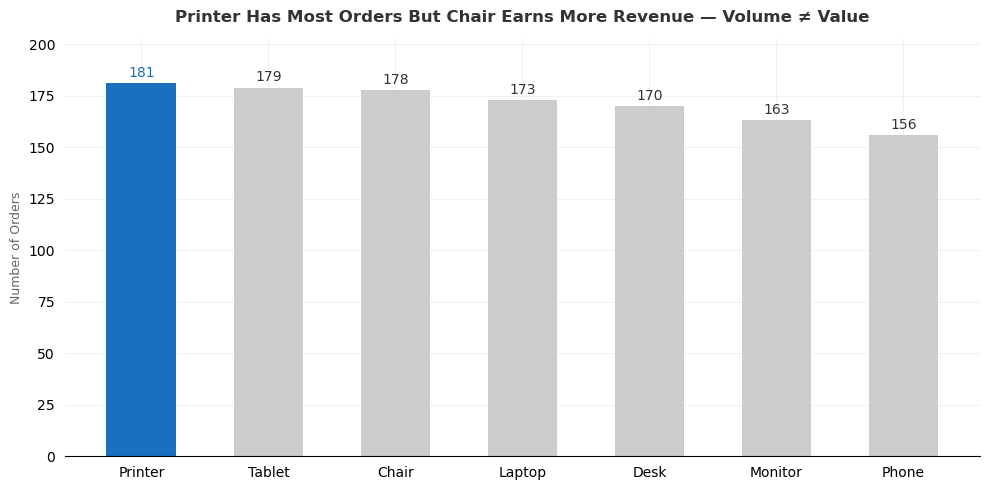

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

prod_cnt = df['Product'].value_counts().sort_values(ascending=False)
max_prod = prod_cnt.idxmax()

# Blue spotlight on product with most orders
colors = [BLUE if p == max_prod else GREY for p in prod_cnt.index]

bars = ax.bar(prod_cnt.index, prod_cnt.values, color=colors, width=0.55)

for bar, val in zip(bars, prod_cnt.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
            str(val),
            ha='center', va='bottom', fontsize=10,
            color=BLUE if val == prod_cnt.max() else DARK)

ax.set_title(f'{max_prod} Has Most Orders But Chair Earns More Revenue — Volume ≠ Value',
             fontsize=12, fontweight='bold', color=DARK, pad=12)
ax.set_ylabel('Number of Orders', fontsize=9, color='#666')
ax.set_ylim(0, prod_cnt.max() * 1.12)

plt.tight_layout()
plt.savefig('chart8_orders_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

## **Chart 9 — Revenue Share by Product (Stacked Bar)**

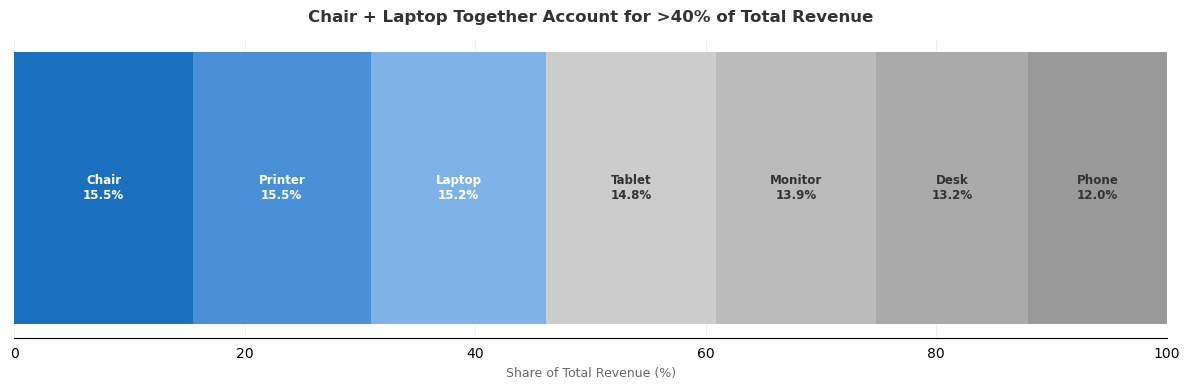

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))

prod_rev2 = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
total_rev = prod_rev2.sum()
pct = prod_rev2 / total_rev * 100

# Blue shades for top products, grey for the rest
palette = [BLUE, '#4A90D9', '#7FB3E8', GREY, '#BBBBBB', '#AAAAAA', '#999999']

left = 0
for i, (prod, val) in enumerate(pct.items()):
    ax.barh(0, val, left=left, color=palette[i], height=0.5)
    if val > 4:   # only label if segment is wide enough
        ax.text(left + val/2, 0,
                f'{prod}\n{val:.1f}%',
                ha='center', va='center', fontsize=8.5,
                color='white' if i < 3 else DARK, fontweight='bold')
    left += val

ax.set_xlim(0, 100)
ax.set_title('Chair + Laptop Together Account for >40% of Total Revenue',
             fontsize=12, fontweight='bold', color=DARK, pad=12)
ax.set_xlabel('Share of Total Revenue (%)', fontsize=9, color='#666')
ax.set_yticks([])

plt.tight_layout()
plt.savefig('chart9_revenue_share_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

## **Step 2 — Save Confirmation**

In [15]:
import os

charts = [
    'chart1_revenue_by_product.png',
    'chart2_monthly_revenue_trend.png',
    'chart3_order_status.png',
    'chart4_referral_revenue.png',
    'chart5_payment_avg_order.png',
    'chart6_unitprice_correlation.png',
    'chart7_totalprice_distribution.png',
    'chart8_orders_by_product.png',
    'chart9_revenue_share_stacked.png',
]

for chart in charts:
    status = "✅" if os.path.exists(chart) else "❌"
    print(f"{status} {chart}")

print("\nAll 9 charts saved successfully!")

✅ chart1_revenue_by_product.png
✅ chart2_monthly_revenue_trend.png
✅ chart3_order_status.png
✅ chart4_referral_revenue.png
✅ chart5_payment_avg_order.png
✅ chart6_unitprice_correlation.png
✅ chart7_totalprice_distribution.png
✅ chart8_orders_by_product.png
✅ chart9_revenue_share_stacked.png

All 9 charts saved successfully!
